<h1>Импорт библиотек

In [17]:
import numpy as np
import matplotlib.pyplot as pltит

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [18]:
def sum_prod(X, V):
    if not X:
        return np.zeros((0, 1))
    total = np.zeros_like(V[0])
    for M, v in zip(X, V):
        total += M @ v
    return total

A1 = np.array([[1, 0], [0, 1]])
v1 = np.array([[2], [3]])
A2 = np.array([[0, 1], [1, 0]])
v2 = np.array([[4], [5]])
result = sum_prod([A1, A2], [v1, v2])
expected = A1 @ v1 + A2 @ v2
assert np.allclose(result, expected)

A3 = np.array([[1, 2], [3, 4]])
v3 = np.array([[1], [1]])
A4 = np.array([[5, 6], [7, 8]])
v4 = np.array([[2], [2]])
result2 = sum_prod([A3, A4], [v3, v4])
expected2 = A3 @ v3 + A4 @ v4
assert np.allclose(result2, expected2)

A5 = np.array([[1]])
v5 = np.array([[10]])
result3 = sum_prod([A5], [v5])
assert np.allclose(result3, A5 @ v5)

result4 = sum_prod([], [])
assert np.allclose(result4, np.zeros((0, 1)))

<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [19]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)

M1 = np.array([[0.2, 0.8], [0.6, 0.1]])
expected1 = np.array([[0, 1], [1, 0]])
assert np.array_equal(binarize(M1), expected1)

M2 = np.array([[0.5, 0.51], [0.49, 0.5]])
expected2 = np.array([[0, 1], [0, 0]])
assert np.array_equal(binarize(M2), expected2)

M3 = np.array([[1, 2], [3, 4]])
expected3 = np.array([[0, 0], [1, 1]])
assert np.array_equal(binarize(M3, threshold=2.5), expected3)

M4 = np.array([[0.0, 0.0], [0.0, 0.0]])
expected4 = np.array([[0, 0], [0, 0]])
assert np.array_equal(binarize(M4), expected4)

M5 = np.array([[1.0, 1.0], [1.0, 1.0]])
expected5 = np.array([[1, 1], [1, 1]])
assert np.array_equal(binarize(M5), expected5)

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [20]:
def unique_rows(mat):
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    return [np.unique(col) for col in mat.T]

mat1 = np.array([[1, 2, 2], [3, 3, 4], [5, 5, 5]])
expected_rows = [np.array([1, 2]), np.array([3, 4]), np.array([5])]
for res, exp in zip(unique_rows(mat1), expected_rows):
    assert np.array_equal(res, exp)

expected_cols = [np.array([1, 3, 5]), np.array([2, 3, 5]), np.array([2, 4, 5])]
for res, exp in zip(unique_columns(mat1), expected_cols):
    assert np.array_equal(res, exp)

mat2 = np.array([[1, 1], [1, 1]])
assert np.array_equal(unique_rows(mat2)[0], np.array([1]))
assert np.array_equal(unique_rows(mat2)[1], np.array([1]))
assert np.array_equal(unique_columns(mat2)[0], np.array([1]))
assert np.array_equal(unique_columns(mat2)[1], np.array([1]))

mat3 = np.array([[1, 2, 3], [4, 5, 6]])
assert np.array_equal(unique_rows(mat3)[0], np.array([1, 2, 3]))
assert np.array_equal(unique_rows(mat3)[1], np.array([4, 5, 6]))
assert np.array_equal(unique_columns(mat3)[0], np.array([1, 4]))
assert np.array_equal(unique_columns(mat3)[1], np.array([2, 5]))
assert np.array_equal(unique_columns(mat3)[2], np.array([3, 6]))

<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

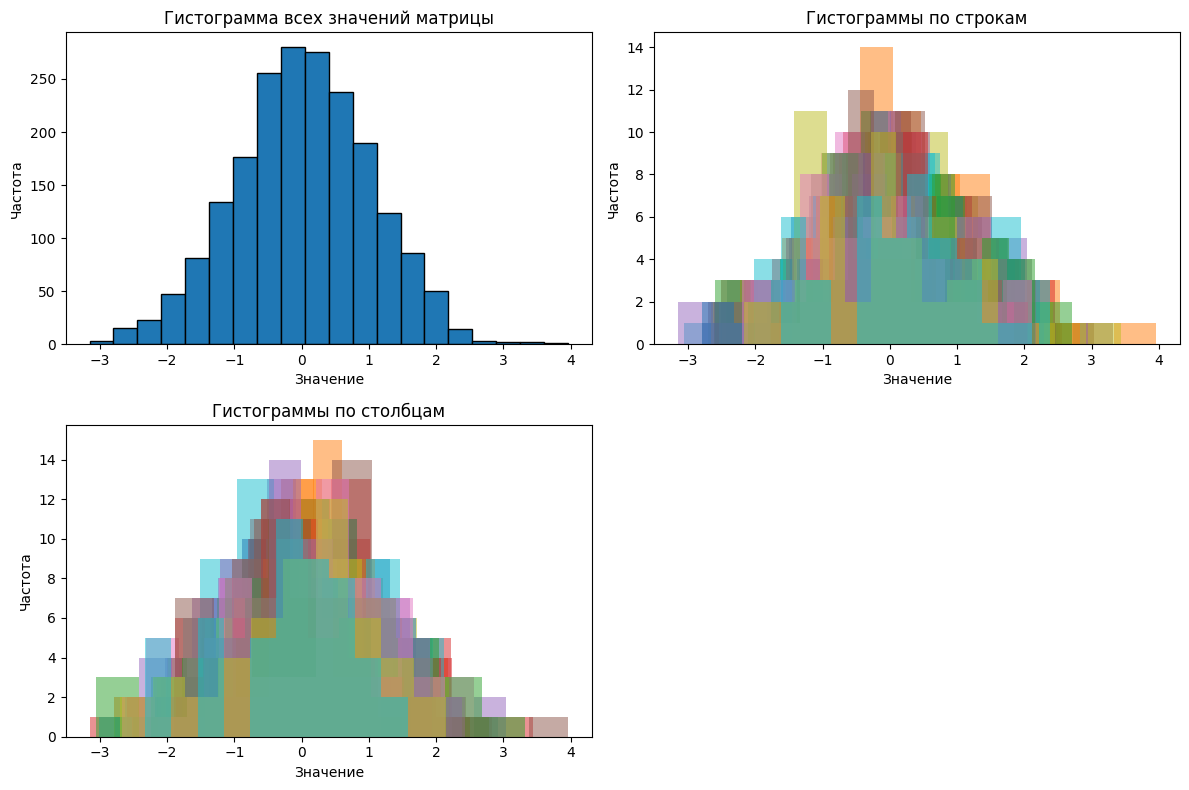

Средние по строкам:
 [ 0.01558876  0.17700332  0.12043144  0.02128887  0.0722293  -0.03039316
  0.00909245 -0.11825815  0.24338974  0.00613147  0.12287128  0.08928109
 -0.01417825  0.02432132 -0.05211028 -0.09058809 -0.10125058  0.03960157
  0.27574414 -0.09966681  0.17047132 -0.05361654 -0.17556163  0.12665232
  0.12887572 -0.04795021 -0.21763727  0.06096061  0.31471236  0.04662438
  0.2175748   0.07104842  0.1540205   0.22706029  0.05748753 -0.06314583
 -0.13364538 -0.30133457 -0.0226235   0.15632514 -0.1144582  -0.01099492
  0.44181236  0.09412314 -0.12128693 -0.01391464 -0.21299128 -0.00869972
 -0.19041258  0.06623316]
Дисперсии по строкам:
 [0.89402514 0.899019   1.06117844 1.28416287 0.56475346 1.41869903
 0.88836603 1.33600197 0.81436264 0.99306698 0.76971681 1.39182916
 1.06088009 0.83591197 0.98780898 1.26481141 0.90903695 0.94412534
 0.64225802 0.96123968 0.74669257 0.90815666 0.9522897  1.12597286
 0.91291046 1.04531516 0.78326178 0.76289619 1.01123155 0.73438818
 0.64788855

In [21]:
def analyze_random_matrix(rows, cols, mean=0, std=1):
    matrix = np.random.normal(mean, std, size=(rows, cols))
    
    row_means = np.mean(matrix, axis=1)
    row_vars = np.var(matrix, axis=1, ddof=0)
    col_means = np.mean(matrix, axis=0)
    col_vars = np.var(matrix, axis=0, ddof=0)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0, 0].hist(matrix.flatten(), bins=20, edgecolor='black')
    axes[0, 0].set_title('Гистограмма всех значений матрицы')
    axes[0, 0].set_xlabel('Значение')
    axes[0, 0].set_ylabel('Частота')
    
    for i in range(rows):
        axes[0, 1].hist(matrix[i, :], bins=10, alpha=0.5, label=f'Строка {i}')
    axes[0, 1].set_title('Гистограммы по строкам')
    axes[0, 1].set_xlabel('Значение')
    axes[0, 1].set_ylabel('Частота')
    
    for j in range(cols):
        axes[1, 0].hist(matrix[:, j], bins=10, alpha=0.5, label=f'Столбец {j}')
    axes[1, 0].set_title('Гистограммы по столбцам')
    axes[1, 0].set_xlabel('Значение')
    axes[1, 0].set_ylabel('Частота')
    
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'matrix': matrix,
        'row_means': row_means,
        'row_vars': row_vars,
        'col_means': col_means,
        'col_vars': col_vars
    }

result = analyze_random_matrix(50, 40, mean=0, std=1)
print("Средние по строкам:\n", result['row_means'])
print("Дисперсии по строкам:\n", result['row_vars'])
print("Средние по столбцам:\n", result['col_means'])
print("Дисперсии по столбцам:\n", result['col_vars'])

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [22]:
def chess(m, n, a, b):
    mat = np.empty((m, n), dtype=type(a))
    for i in range(m):
        for j in range(n):
            mat[i, j] = a if (i + j) % 2 == 0 else b
    return mat

m1, n1 = 3, 3
a1, b1 = 1, 0
expected1 = np.array([[1, 0, 1],
                      [0, 1, 0],
                      [1, 0, 1]])
assert np.array_equal(chess(m1, n1, a1, b1), expected1)

m2, n2 = 2, 4
a2, b2 = 7, 8
expected2 = np.array([[7, 8, 7, 8],
                      [8, 7, 8, 7]])
assert np.array_equal(chess(m2, n2, a2, b2), expected2)

m3, n3 = 1, 1
a3, b3 = 42, 0
expected3 = np.array([[42]])
assert np.array_equal(chess(m3, n3, a3, b3), expected3)

m4, n4 = 4, 1
a4, b4 = 'x', 'y'
expected4 = np.array([['x'],
                      ['y'],
                      ['x'],
                      ['y']])
assert np.array_equal(chess(m4, n4, a4, b4), expected4)

<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

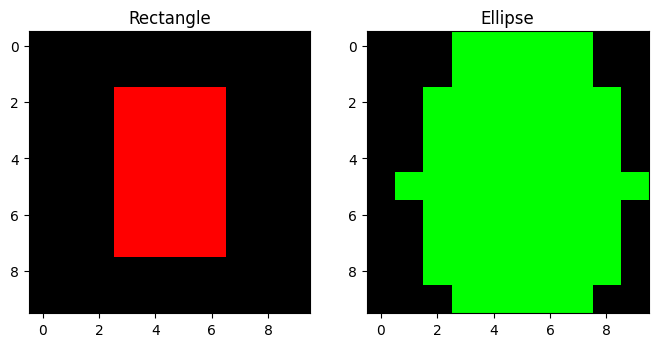

In [23]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    x0, y0 = n // 2, m // 2
    x_start = max(0, x0 - a // 2)
    x_end = min(n, x0 + a // 2)
    y_start = max(0, y0 - b // 2)
    y_end = min(m, y0 + b // 2)
    img[y_start:y_end, x_start:x_end] = rectangle_color
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    x0, y0 = n // 2, m // 2
    y, x = np.ogrid[:m, :n]
    mask = ((x - x0) / a) ** 2 + ((y - y0) / b) ** 2 <= 1
    img[mask] = ellipse_color
    return img

rect_img = draw_rectangle(4, 6, 10, 10, (255, 0, 0), (0, 0, 0))
assert rect_img.shape == (10, 10, 3)
assert np.array_equal(rect_img[0, 0], [0, 0, 0])  # угол чёрный
assert np.array_equal(rect_img[5, 5], [255, 0, 0])  # центр красный

ellipse_img = draw_ellipse(4, 6, 10, 10, (0, 255, 0), (0, 0, 0))
assert ellipse_img.shape == (10, 10, 3)
assert np.array_equal(ellipse_img[0, 0], [0, 0, 0])
assert np.array_equal(ellipse_img[5, 5], [0, 255, 0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rect_img)
axes[0].set_title('Rectangle')
axes[1].imshow(ellipse_img)
axes[1].set_title('Ellipse')
plt.show()

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

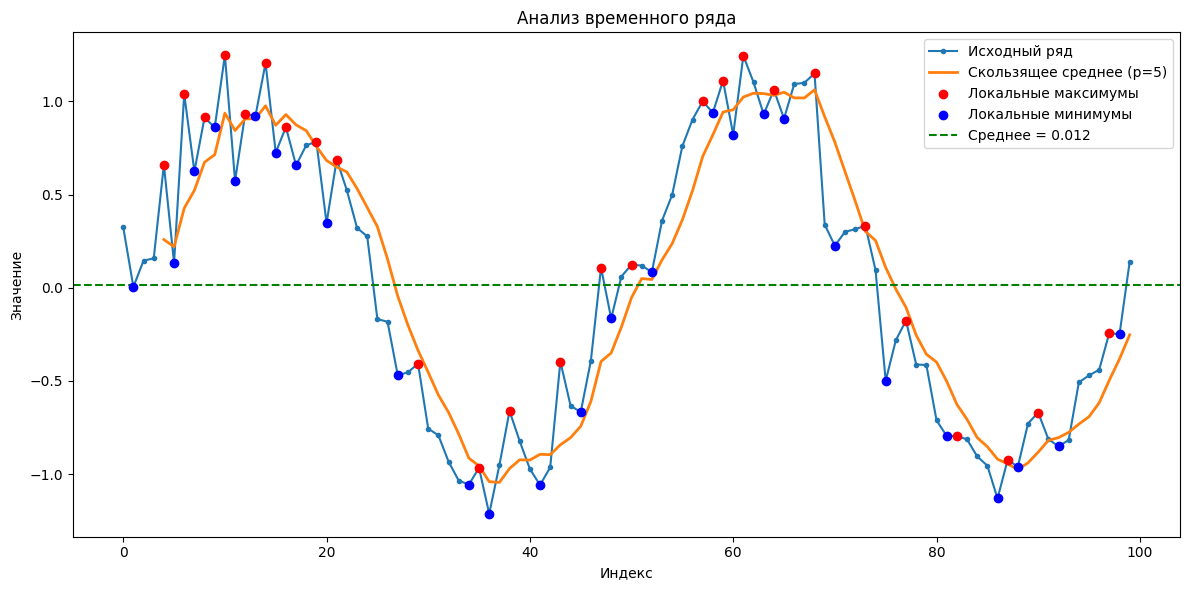

Математическое ожидание: 0.012116570415139732
Дисперсия: 0.5331468977041506
СКО: 0.7301690884337344
Локальные максимумы (индекс, значение): [(4, np.float64(0.6592782619654044)), (6, np.float64(1.0390413643254082)), (8, np.float64(0.9135332491609341))] ...
Локальные минимумы (индекс, значение): [(1, np.float64(0.004241170843734182)), (5, np.float64(0.13260018967858384)), (7, np.float64(0.6239050841127363))] ...


In [24]:
def analyze_timeseries(series, p):
    mean = np.mean(series)
    var = np.var(series, ddof=0)
    std = np.std(series, ddof=0)
    
    local_max = []
    local_min = []
    for i in range(1, len(series) - 1):
        if series[i] > series[i-1] and series[i] > series[i+1]:
            local_max.append((i, series[i]))
        elif series[i] < series[i-1] and series[i] < series[i+1]:
            local_min.append((i, series[i]))
    
    moving_avg = np.convolve(series, np.ones(p)/p, mode='valid')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(series, label='Исходный ряд', marker='o', markersize=3)
    ax.plot(range(p-1, len(series)), moving_avg, label=f'Скользящее среднее (p={p})', linewidth=2)
    max_indices, max_values = zip(*local_max) if local_max else ([], [])
    min_indices, min_values = zip(*local_min) if local_min else ([], [])
    ax.scatter(max_indices, max_values, color='red', label='Локальные максимумы', zorder=5)
    ax.scatter(min_indices, min_values, color='blue', label='Локальные минимумы', zorder=5)
    ax.axhline(mean, color='green', linestyle='--', label=f'Среднее = {mean:.3f}')
    ax.legend()
    ax.set_title('Анализ временного ряда')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Значение')
    plt.tight_layout()
    plt.show()
    
    return {
        'mean': mean,
        'variance': var,
        'std': std,
        'local_maxima': local_max,
        'local_minima': local_min,
        'moving_average': moving_avg
    }

np.random.seed(1)
t = np.linspace(0, 4*np.pi, 100)
series = np.sin(t) + 0.2 * np.random.randn(100)

result = analyze_timeseries(series, p=5)
print("Математическое ожидание:", result['mean'])
print("Дисперсия:", result['variance'])
print("СКО:", result['std'])
print("Локальные максимумы (индекс, значение):", result['local_maxima'][:3], "...")
print("Локальные минимумы (индекс, значение):", result['local_minima'][:3], "...")

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [25]:
def one_hot_encode(labels):
    num_classes = np.max(labels) + 1 if len(labels) > 0 else 0
    one_hot = np.zeros((len(labels), num_classes), dtype=int)
    for i, label in enumerate(labels):
        one_hot[i, label] = 1
    return one_hot

labels1 = np.array([0, 2, 3, 0])
expected1 = np.array([[1, 0, 0, 0],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1],
                      [1, 0, 0, 0]])
assert np.array_equal(one_hot_encode(labels1), expected1)

labels2 = np.array([1, 0, 1, 2])
expected2 = np.array([[0, 1, 0],
                      [1, 0, 0],
                      [0, 1, 0],
                      [0, 0, 1]])
assert np.array_equal(one_hot_encode(labels2), expected2)

labels3 = np.array([0])
expected3 = np.array([[1]])
assert np.array_equal(one_hot_encode(labels3), expected3)

labels4 = np.array([4])
expected4 = np.array([[0, 0, 0, 0, 1]])
assert np.array_equal(one_hot_encode(labels4), expected4)

labels5 = np.array([])
expected5 = np.zeros((0, 0), dtype=int)
assert np.array_equal(one_hot_encode(labels5), expected5)